---
title: "Exploratory Data Analysis"
format:
    html: 
        code-fold: false
---

## Imports

In [20]:
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

## Class Distribution

In [8]:
# Define base directory for processed data
processed = "../data/processed"

# List all stages
stages = ["stage1_quadrant", "stage2_enumeration", "stage3_disease"]

# Define dataset splits
splits = ["train", "val", "test"]

# Loop through each stage
for stage in stages:
    print(f"\n{stage}:")
    
    # Loop through each split
    for split in splits:
        img_dir = os.path.join(processed, stage, "images", split)
        
        # Check if the split exists
        if os.path.exists(img_dir):
            
            # Count number of images
            count = len(os.listdir(img_dir))
            
            # Print results
            print(f"{split}: {count} images")


stage1_quadrant:
train: 1398 images
val: 50 images

stage2_enumeration:
train: 1339 images
val: 50 images

stage3_disease:
train: 705 images
val: 50 images
test: 250 images


As we can see from the results above, the dataset consists of three stages with varying sizes. Stage 1 and Stage 2 have more training images, while Stage 3 has fewer training samples but includes a separate test set. All stages share a consistent validation size, reflecting a structured split across tasks of increasing complexity.

## Task and Label Characteristics

In [23]:
# Task summary table
task_df = pd.DataFrame({
    "Stage": ["Stage 1", "Stage 2", "Stage 3"],
    "Task": ["Quadrant detection", "Tooth detection", "Disease detection"],
    "Object Type": ["Large regions", "Medium objects", "Small, detailed regions"],
    "Characteristics": [
        "Few labels per image",
        "Many labels per image",
        "Many, small, and detailed labels"
    ],
})
task_df

,Stage,Task,Object Type,Characteristics
0,Stage 1,Quadrant detection,Large regions,Few labels per image
1,Stage 2,Tooth detection,Medium objects,Many labels per image
2,Stage 3,Disease detection,"Small, detailed regions","Many, small, and detailed labels"


As we can see from the table above, the three stages differ in both task complexity and label characteristics. Stage 1 focuses on detecting large quadrant regions and contains relatively few labels per image, making it the simplest task. Stage 2 involves detecting individual teeth, which increases the number of objects per image and introduces moderate complexity. Stage 3 is the most challenging, as it requires detecting many small and localized disease regions. These objects are both numerous and fine-grained, significantly increasing the difficulty of accurate detection.

## Main Explore Data Analysis

### Class Distribution

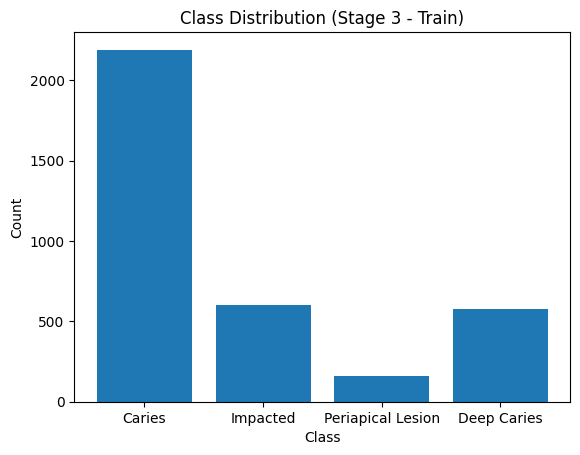

In [19]:
# Set label directory
label_dir = "../data/processed/stage3_disease/labels/train"

class_counts = Counter()

# Read all label files
for file in os.listdir(label_dir):
    file_path = os.path.join(label_dir, file)
    
    with open(file_path, "r") as f:
        lines = f.readlines()
        
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] += 1

# Map class IDs to names
class_names = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical Lesion",
    3: "Deep Caries"
}

# Prepare data for plotting
labels = [class_names[k] for k in class_counts.keys()]
values = list(class_counts.values())

# Plot bar chart
plt.figure()
plt.bar(labels, values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Stage 3 - Train)")
plt.show()

As we can see from the plot above, we see that there is a clear imbalance in the dataset. Caries is the most frequent class by a large margin, while periapical lesions are significantly underrepresented. Impacted teeth and deep caries appear in moderate amounts. This imbalance may lead the model to favor the majority class and reduce performance on rarer conditions.

### Bounding Box Size

Total boxes: 3529
Mean area: 0.2541627127637164
Median area: 0.242547914214
Min area: 0.042866833603999996
Max area: 0.561391342733


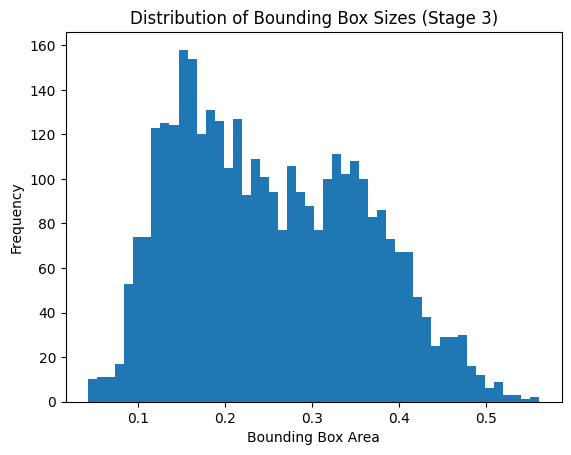

In [22]:
# Set label
areas = []
widths = []
heights = []

# Read all label files
for file in os.listdir(label_dir):
    file_path = os.path.join(label_dir, file)
    with open(file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            parts = line.split()
            # Extract width and height
            w = float(parts[3])
            h = float(parts[4])
            widths.append(w)
            heights.append(h)
            areas.append(w * h)

# Print summary statistics
print("Total boxes:", len(areas))
print("Mean area:", np.mean(areas))
print("Median area:", np.median(areas))
print("Min area:", np.min(areas))
print("Max area:", np.max(areas))

# Plot area distribution
plt.figure()
plt.hist(areas, bins=50)
plt.xlabel("Bounding Box Area")
plt.ylabel("Frequency")
plt.title("Distribution of Bounding Box Sizes (Stage 3)")
plt.show()

The distribution of bounding box sizes shows that most objects fall within a moderate size range, with areas concentrated between small and medium values. While extremely small objects are less common, there is still noticeable variation in object size. This indicates that the model must handle objects at multiple scales, which can increase detection complexity.

## Spatial Distribution

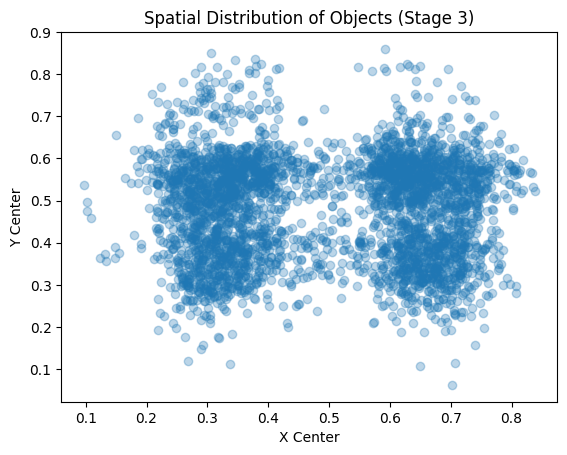

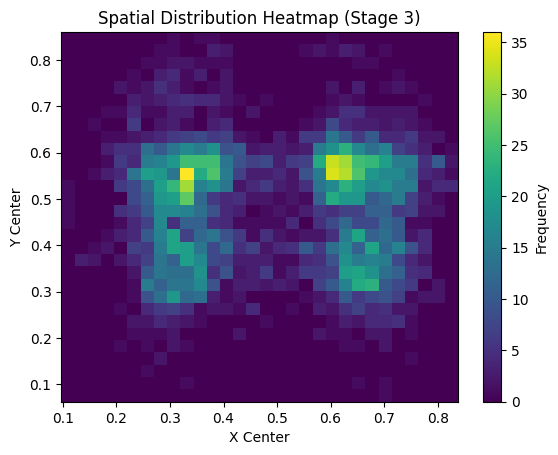

In [25]:
# Add position of each object variable
x_centers = []
y_centers = []

# Iterate through label files
for file in os.listdir(label_dir):
    file_path = os.path.join(label_dir, file)
    with open(file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            parts = line.split()
            x = float(parts[1])
            y = float(parts[2])
            x_centers.append(x)
            y_centers.append(y)

# Scatter plot
plt.figure()
plt.scatter(x_centers, y_centers, alpha=0.3)
plt.xlabel("X Center")
plt.ylabel("Y Center")
plt.title("Spatial Distribution of Objects (Stage 3)")
plt.show()

# Heat map
plt.figure()
plt.hist2d(x_centers, y_centers, bins=30)
plt.colorbar(label="Frequency")
plt.xlabel("X Center")
plt.ylabel("Y Center")
plt.title("Spatial Distribution Heatmap (Stage 3)")
plt.show()

As we can see from the plot above, we see that the spatial distribution of bounding boxes reveals a clear clustering pattern, with objects concentrated in two distinct regions corresponding to the left and right sides of the image. Very few objects appear in the central area, indicating that disease regions are not uniformly distributed. This structured spatial pattern suggests that region-based approaches, such as splitting the image into meaningful sections, may improve detection performance.

## Objects per Image

Mean objects per image: 5.005673758865248
Median objects per image: 4.0
Min objects: 0
Max objects: 23


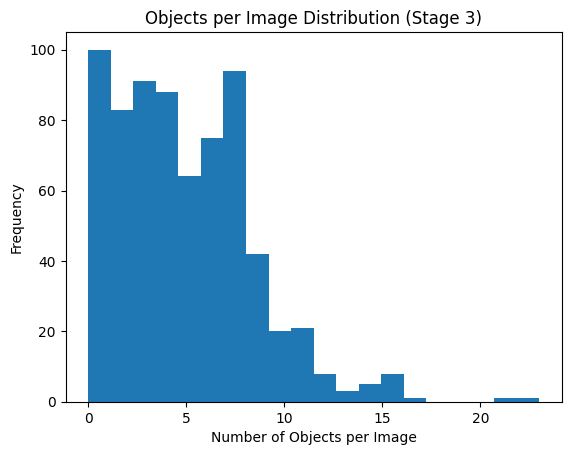

In [27]:
# Add obj per img variable
objects_per_image = []

# Iterate through label files
for file in os.listdir(label_dir):
    file_path = os.path.join(label_dir, file)
    
    with open(file_path, "r") as f:
        lines = f.readlines()
        
        # Count number of objects in this image
        objects_per_image.append(len(lines))

# Print statistics
print("Mean objects per image:", np.mean(objects_per_image))
print("Median objects per image:", np.median(objects_per_image))
print("Min objects:", np.min(objects_per_image))
print("Max objects:", np.max(objects_per_image))

# Plot 
plt.figure()
plt.hist(objects_per_image, bins=20)
plt.xlabel("Number of Objects per Image")
plt.ylabel("Frequency")
plt.title("Objects per Image Distribution (Stage 3)")
plt.show()

As we can see from the results above, we see that the distribution of objects per image shows that most images contain multiple disease regions, with an average of around five objects per image. The distribution is right-skewed, indicating that while many images contain a moderate number of objects, some images are highly dense with many annotations. Additionally, a small number of images contain no objects. This variation in object density increases the complexity of the detection task, as the model must accurately localize multiple objects and handle both sparse and crowded scenarios.

## Summary

The exploratory analysis reveals several key challenges in the dataset. First, there is a clear class imbalance, with caries dominating the annotations while other conditions are underrepresented. Second, the distribution of bounding box sizes shows variability in object scale, requiring the model to handle both small and medium-sized regions. Third, spatial analysis indicates that disease regions are concentrated in specific areas of the image rather than being uniformly distributed. Finally, most images contain multiple objects, with some cases being highly dense. Together, these characteristics increase the complexity of the detection task. They suggest that standard object detection models may struggle, and motivate the use of region-focused approaches and techniques that can better handle multi-scale and dense object scenarios.

These characteristics suggest the need for a model that can handle multiple objects, varying object sizes, and structured spatial patterns.

## Model Selection

Based on the findings from the exploratory data analysis, YOLOv8 is selected as the baseline model.

YOLOv8 is selected as the baseline model due to its strong performance in object detection tasks and its ability to perform real-time detection. It provides a good balance between accuracy and efficiency, and supports detection of multiple objects within a single image. Additionally, YOLOv8 is well-suited for handling datasets with varying object sizes, which is important for this project.